# **Satellite Data Without the Download: Sentinel-2 NDVI from a STAC Catalog**

Find cloud-free Sentinel-2 scenes over a flux site with a STAC search, read only the pixels you need from cloud-optimized GeoTIFFs, and build an NDVI time series to compare with tower LAI.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Explain what a STAC catalog and a cloud-optimized GeoTIFF are and why they changed satellite data access.
- Search the Earth Search catalog for Sentinel-2 L2A scenes by location, date, and cloud cover.
- Read a small window of red and near-infrared bands with `rasterio` and compute NDVI.
- Build a one-year NDVI time series at Vaira Ranch and compare it with the tower's LAI record.

**Before you start:** Requires an internet connection. Packages: `pystac-client`, `rasterio`. On Colab run `!pip install pystac-client rasterio` first.

## **STAC and cloud-optimized GeoTIFFs**

Until recently, using satellite data meant downloading whole scenes (hundreds of megabytes each) before looking at a
single pixel. Two standards changed that:

- **STAC** (SpatioTemporal Asset Catalog) is a common JSON format for describing imagery: where it is, when it was taken,
  what bands exist, how cloudy it is, and where the files live. A STAC *API* lets you search a catalog by bounding box,
  date range, and properties such as cloud cover.
- **Cloud-optimized GeoTIFF (COG)** is a GeoTIFF arranged so that a reader can fetch just the tiles it needs over HTTP.
  Reading 100 by 100 pixels out of a 10,000 by 10,000 pixel image costs a few kilobytes, not a gigabyte.

Together, they let you compute a vegetation index at one flux site for a whole year in a minute, from a laptop.

**NDVI** (normalized difference vegetation index) uses the fact that green leaves absorb red light and reflect
near-infrared light:

$$ NDVI = \frac{NIR - Red}{NIR + Red} \qquad (1) $$

Bare soil and dry grass are near 0.1-0.2; dense green vegetation is 0.6-0.9. We use Sentinel-2 bands B04 (red, 665 nm) and
B08 (NIR, 842 nm) at 10 m resolution.

**Catalog used:** Earth Search by Element 84 (`https://earth-search.aws.element84.com/v1`), collection `sentinel-2-l2a`,
which is free and requires no account. The COGs are in a public AWS bucket, read with no sign-in.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from pystac_client import Client
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv'}

## **Step 1: Search the catalog**

A 1 km box around the US-Var tower (38.4133 N, 120.9507 W), water year 2019 (October 2018 to September 2019), scenes with less than 20% cloud cover.

In [2]:
lat, lon = 38.4133, -120.9507
half = 0.005                                       # ~0.5 km in degrees
bbox = [lon - half, lat - half, lon + half, lat + half]

catalog = Client.open('https://earth-search.aws.element84.com/v1')
search = catalog.search(collections=['sentinel-2-l2a'], bbox=bbox, datetime='2018-10-01/2019-09-30',
                        query={'eo:cloud_cover': {'lt': 20}}, max_items=200)
items = sorted(search.item_collection(), key=lambda it: it.datetime)
print(f'{len(items)} scenes found')
print('first item assets:', list(items[0].assets.keys())[:12])
scene_table = pd.DataFrame({'date': [it.datetime.date() for it in items], 'cloud_cover': [it.properties['eo:cloud_cover'] for it in items],
                            'tile': [it.properties.get('grid:code', '') for it in items]})
scene_table.head(10)

65 scenes found
first item assets: ['aot', 'blue', 'coastal', 'granule_metadata', 'green', 'nir', 'nir08', 'nir09', 'red', 'rededge1', 'rededge2', 'rededge3']


,date,cloud_cover,tile
0,2018-10-02,10.637950,MGRS-10SFH
1,2018-10-02,15.574700,MGRS-10SFH
2,2018-10-07,0.233523,MGRS-10SFH
3,2018-10-12,0.213258,MGRS-10SFH
4,2018-10-17,0.182926,MGRS-10SFH
5,2018-10-22,0.167617,MGRS-10SFH
6,2018-10-22,0.000458,MGRS-10SFH
7,2018-11-06,2.903306,MGRS-10SFH
8,2018-11-11,3.681022,MGRS-10SFH
9,2018-11-16,8.111351,MGRS-10SFH


## **Step 2: Read a window of one scene and compute NDVI**

Scene 2019-04-25, window shape (113, 90), mean NDVI 0.79


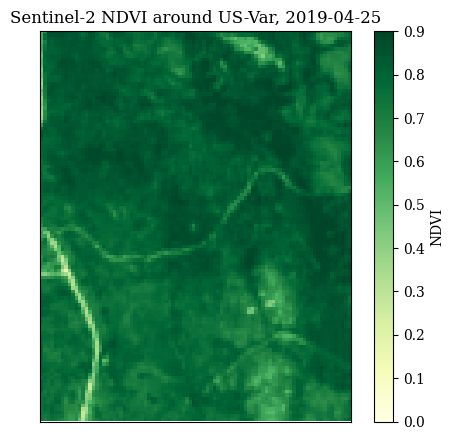

In [3]:
def read_window(href, bbox_lonlat):
    """Read the pixels inside bbox (lon/lat) from a COG, returning the array and the window transform."""
    with rasterio.open(href) as src:
        b = transform_bounds('EPSG:4326', src.crs, *bbox_lonlat)
        win = from_bounds(*b, transform=src.transform)
        arr = src.read(1, window=win).astype('float32')
        return arr, src.window_transform(win)

def ndvi_for_item(item, bbox_lonlat, scale=1e-4, offset=-0.1):
    """Sentinel-2 L2A on Earth Search: reflectance = DN * 1e-4 + offset (offset applies to data after Jan 2022; before that offset = 0)."""
    red, _ = read_window(item.assets['red'].href, bbox_lonlat)
    nir, _ = read_window(item.assets['nir'].href, bbox_lonlat)
    if item.datetime.year < 2022: offset = 0.0
    red = red * scale + offset; nir = nir * scale + offset
    return (nir - red) / (nir + red + 1e-6)

it = [i for i in items if i.datetime.month == 4][0]      # an April scene: peak green in a Mediterranean grassland
ndvi = ndvi_for_item(it, bbox)
print(f'Scene {it.datetime.date()}, window shape {ndvi.shape}, mean NDVI {np.nanmean(ndvi):.2f}')
fig, ax = plt.subplots(figsize=(5, 4.5)); im = ax.imshow(ndvi, cmap='YlGn', vmin=0, vmax=0.9); plt.colorbar(im, label='NDVI'); ax.set_title(f'Sentinel-2 NDVI around US-Var, {it.datetime.date()}'); ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout()

## **Step 3: A one-year time series**

Use a 300 m box (30 by 30 pixels) around the tower, close to the flux footprint, and take the median NDVI per scene.

In [4]:
small = [lon - 0.0017, lat - 0.0014, lon + 0.0017, lat + 0.0014]
rows = []
for it in items:
    try:
        v = ndvi_for_item(it, small); rows.append({'date': pd.Timestamp(it.datetime.date()), 'ndvi': float(np.nanmedian(v)), 'cloud': it.properties['eo:cloud_cover']})
    except Exception as e:
        print('skipped', it.datetime.date(), type(e).__name__)
ts = pd.DataFrame(rows).groupby('date').median().sort_index()
print(f'{len(ts)} dates')

40 dates


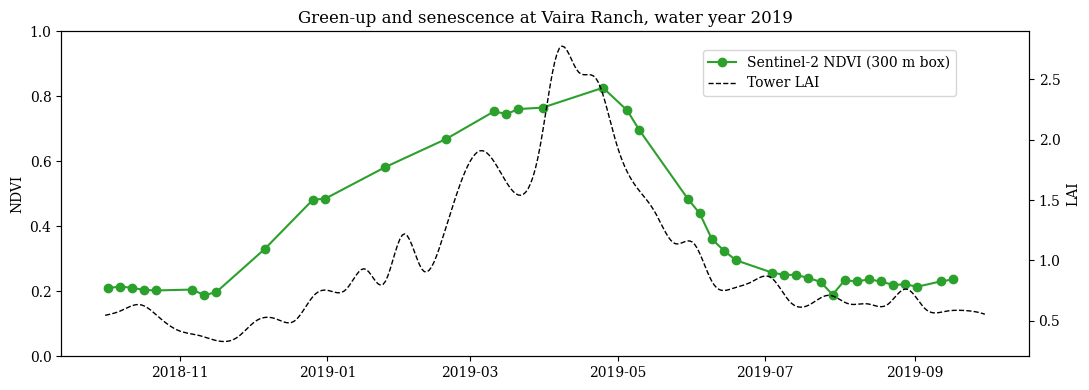

In [5]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv']); df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date')
lai = df.loc['2018-10-01':'2019-09-30', 'LAI']
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts.index, ts['ndvi'], 'o-', color='tab:green', label='Sentinel-2 NDVI (300 m box)'); ax.set_ylabel('NDVI'); ax.set_ylim(0, 1)
ax2 = ax.twinx(); ax2.plot(lai.index, lai, 'k--', lw=1, label='Tower LAI'); ax2.set_ylabel('LAI')
ax.set_title('Green-up and senescence at Vaira Ranch, water year 2019'); fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88)); plt.tight_layout()

**What to notice.** NDVI rises after the autumn rains, peaks in spring, and collapses by June when the annual grasses
die. It tracks the tower LAI closely because both respond to the same water-driven phenology. Gaps in the satellite
series are cloudy periods; in a wet winter they are long, which is a real limitation of optical remote sensing and the
reason thermal, radar, and flux-tower data complement it.

## **Exercises**

**Exercise 1.** Change the cloud-cover threshold to 50% and add a per-pixel cloud mask using the `scl` (scene classification) asset: keep only classes 4 (vegetation), 5 (bare soil), and 6 (water). Does the time series get cleaner or noisier?

**Exercise 2.** Repeat the time series for a drought year (water year 2014) and a wet year (2017). Compare the date of peak NDVI and the length of the green season.

**Exercise 3.** Compute NDVI for a 2 km box and plot the spatial standard deviation for each date. When is the landscape most heterogeneous, and why?

**Exercise 4.** Swap the red band for the red-edge band B05 and compute the normalized difference red-edge index. Which index saturates first at high LAI?

## **References**

- STAC specification: https://stacspec.org. Earth Search catalog: https://earth-search.aws.element84.com/v1.
- Tucker, C. J. (1979). Red and photographic infrared linear combinations for monitoring vegetation. *Remote Sensing of Environment*, 8, 127-150.
- ESA (2021). *Sentinel-2 Level-2A Algorithm Theoretical Basis Document.*
- Ma, S., Baldocchi, D. D., Xu, L., & Hehn, T. (2007). Inter-annual variability in carbon dioxide exchange of an oak/grass savanna and open grassland in California. *Agricultural and Forest Meteorology*, 147, 157-171.